In [1]:
# ============================================================
# Real-Dataset Validation: Empirical Scaling Law
#
# SCALING LAW (from timescale experiment, R²=0.956):
#   T_collapse ~ N_min^{-0.70} · ratio^{-1.05} · p^{0.54}
#
# Collapse within training budget T when:
#   MAD‡ = T · N_min^{0.70} · ratio^{1.05} / p^{0.54} > C
#
# Rounding to clean mechanistic exponents:
#   MAD‡ ≈ T · N_min^{2/3} · ratio / sqrt(p)
#
# THIS NOTEBOOK:
#   1. Computes MAD‡ for every real dataset using paper values
#   2. Fits threshold C via leave-one-out cross-validation
#   3. Compares to original MAD_W and corrected MAD†
#   4. Checks whether a single C separates all outcomes
#   5. Sensitivity analysis: exact vs rounded exponents
#
# DATASETS (from published paper + notebooks):
#   Fitzpatrick17k, DDI, PH2, PAD-UFES-20, CelebA,
#   Waterbirds-canonical, NIH-Infiltration
#
# NO GPU NEEDED. Pure computation.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.optimize import minimize_scalar
import json, math, warnings
warnings.filterwarnings('ignore')

# ── Fitted exponents from timescale experiment ─────────────
A_EXACT = 0.7043   # N_min exponent (negated: larger N → faster collapse)
B_EXACT = 1.0479   # ratio exponent
C_EXACT = 0.5382   # p exponent

A_ROUND = 2/3
B_ROUND = 1.0
C_ROUND = 0.5

T_PAPER = 5        # training epochs in paper (frozen probe)
ETA     = 0.1      # DRO step size used in paper

print('Real-Dataset Validation: Empirical Scaling Law')
print(f'Exact exponents:   N_min^{A_EXACT} · ratio^{B_EXACT} / p^{C_EXACT}')
print(f'Rounded exponents: N_min^{A_ROUND:.3f} · ratio^{B_ROUND} / sqrt(p)')
print(f'Training budget:   T={T_PAPER} epochs, eta={ETA}')

Real-Dataset Validation: Empirical Scaling Law
Exact exponents:   N_min^0.7043 · ratio^1.0479 / p^0.5382
Rounded exponents: N_min^0.667 · ratio^1.0 / sqrt(p)
Training budget:   T=5 epochs, eta=0.1


In [2]:
# ── CELL 2: Dataset registry ───────────────────────────────
# All values from published paper, Table 2, Section III,
# and notebooks 01_measure_geometry, notebook-3 (Waterbirds)
#
# Fields:
#   N_min : minority demographic training pool size
#   N_maj : majority demographic training pool size
#   p     : nc/Ng = minority CLASS fraction within minority demographic
#   T     : training epochs (frozen probe = 5)
#   eta   : DRO step size (0.1 primary)
#   observed_collapse : ground truth from experiments
#   orig_mad_w_pred   : what original MAD_W predicted
#   mu_cos_min        : from paper Table 2 (for context)
#   orig_mad_w        : score value

datasets = [
    {
        'name': 'Fitzpatrick17k',
        'domain': 'clinical_dermatology',
        'N_min': 2168,      # dark-skin demographic pool
        'N_maj': 7755,      # light-skin training pool
        'p':     0.094,     # nc/Ng: 203 benign / 2168 dark-skin
        'T':     5,
        'eta':   0.1,
        'observed_collapse': True,
        'orig_mad_w':      0.082,
        'orig_mad_w_pred': 'LOW_RISK',   # missed by original
        'mu_cos_min':      0.716,
        'note': 'Calibration cohort. 5/5 collapse. Original MAD_W missed it (0.082 < 0.131).'
    },
    {
        'name': 'DDI',
        'domain': 'clinical_dermatology',
        'N_min': 208,       # matched training size (paper Section III-D)
        'N_maj': 832,       # approximate (4:1 from matched experiment)
        'p':     0.232,     # nc/Ng
        'T':     5,
        'eta':   0.1,
        'observed_collapse': False,
        'orig_mad_w':      0.104,
        'orig_mad_w_pred': 'LOW_RISK',
        'mu_cos_min':      0.715,
        'note': 'True negative. nc/Ng=23.2% above count floor. No collapse 5/5.'
    },
    {
        'name': 'PH2',
        'domain': 'dermoscopy',
        'N_min': 40,        # approximate from paper
        'N_maj': 160,
        'p':     0.200,     # nc/Ng
        'T':     5,
        'eta':   0.1,
        'observed_collapse': False,
        'orig_mad_w':      0.040,
        'orig_mad_w_pred': 'LOW_RISK',
        'mu_cos_min':      0.907,
        'note': 'True negative. Geometrically compact (mu=0.907). No collapse 5/5.'
    },
    {
        'name': 'PAD-UFES-20',
        'domain': 'clinical_photography',
        'N_min': 1,         # single FST VI image
        'N_maj': 30,        # Nmaj/Nmin ~ 30 (paper Section III-D)
        'p':     0.356,     # nc/Ng
        'T':     5,
        'eta':   0.1,
        'observed_collapse': True,
        'orig_mad_w':      0.214,
        'orig_mad_w_pred': 'ELEVATED',
        'mu_cos_min':      0.796,
        'note': 'Extreme demographic skew. 5/5 collapse. Original MAD_W caught it.'
    },
    {
        'name': 'CelebA',
        'domain': 'non_medical_vision',
        'N_min': 19177,     # non-pale skin demographic
        'N_maj': 162770,    # pale skin demographic
        'p':     0.022,     # nc/Ng: Bald attribute
        'T':     5,
        'eta':   0.1,
        'observed_collapse': True,
        'orig_mad_w':      None,   # not in paper Table 2
        'orig_mad_w_pred': 'ELEVATED (inferred)',
        'mu_cos_min':      0.680,  # approximate
        'note': 'nc/Ng=2.2%, just above MAD-I gate. 5/5 collapse confirmed (paper III-A).'
    },
    {
        'name': 'Waterbirds_canonical',
        'domain': 'vision_spurious_correlation',
        'N_min': 3736,      # minority-context pool
        'N_maj': 8052,      # majority-context pool
        'p':     0.228,     # waterbird fraction within minority context
        'T':     5,
        'eta':   0.1,
        'observed_collapse': True,   # waterbird acc=0.000%, 5/5
        'orig_mad_w':      0.069,
        'orig_mad_w_pred': 'LOW_RISK',  # original missed it
        'mu_cos_min':      0.652,
        'note': 'Original MAD missed. Different mechanism (symmetric collapse). '
                'Key test: does scaling law catch it?'
    },
    {
        'name': 'NIH_Infiltration',
        'domain': 'chest_radiology',
        'N_min': 500,       # female positive pool (approximate)
        'N_maj': 35000,     # male + female negative pool
        'p':     0.014,     # nc/Ng < MAD-I gate
        'T':     5,
        'eta':   0.1,
        'observed_collapse': True,
        'orig_mad_w':      None,
        'orig_mad_w_pred': 'CONTRAINDICATED (gate)',
        'mu_cos_min':      0.850,
        'note': 'nc/Ng=1.4% < MAD-I gate (2%). Both original and scaling law: gate fires.'
    },
    {
        'name': 'ISIC2019',
        'domain': 'dermoscopy',
        'N_min': 1500,      # institutional minority pool (approximate)
        'N_maj': 23831,     # institutional majority
        'p':     0.200,     # malignant class fraction (approximate)
        'T':     5,
        'eta':   0.1,
        'observed_collapse': True,   # 30/30 collapse across 6 pool sizes
        'orig_mad_w':      0.137,
        'orig_mad_w_pred': 'ELEVATED',
        'mu_cos_min':      0.700,   # approximate
        'note': 'Second asymmetry-flagged positive. 30/30 collapse. MAD_W caught via asymmetry.'
    },
]

print(f'Datasets registered: {len(datasets)}')
for d in datasets:
    ratio = d['N_maj'] / d['N_min'] if d['N_min'] > 0 else float('inf')
    print(f"  {d['name']:<25} N=({d['N_maj']:>7},{d['N_min']:>6}) "
          f"ratio={ratio:>6.1f}x  p={d['p']:.3f}  collapse={d['observed_collapse']}")

Datasets registered: 8
  Fitzpatrick17k            N=(   7755,  2168) ratio=   3.6x  p=0.094  collapse=True
  DDI                       N=(    832,   208) ratio=   4.0x  p=0.232  collapse=False
  PH2                       N=(    160,    40) ratio=   4.0x  p=0.200  collapse=False
  PAD-UFES-20               N=(     30,     1) ratio=  30.0x  p=0.356  collapse=True
  CelebA                    N=( 162770, 19177) ratio=   8.5x  p=0.022  collapse=True
  Waterbirds_canonical      N=(   8052,  3736) ratio=   2.2x  p=0.228  collapse=True
  NIH_Infiltration          N=(  35000,   500) ratio=  70.0x  p=0.014  collapse=True
  ISIC2019                  N=(  23831,  1500) ratio=  15.9x  p=0.200  collapse=True


In [3]:
# ── CELL 3: Compute MAD‡ for each dataset ──────────────────
MAD_I_GATE = 0.02

def compute_mad_dagger(N_min, N_maj, p, T, eta,
                       a=A_EXACT, b=B_EXACT, c=C_EXACT):
    if p < MAD_I_GATE:
        return None  # gate fires → CONTRAINDICATED
    if N_min <= 0:
        return float('inf')
    ratio = N_maj / N_min
    return eta * T * (N_min ** a) * (ratio ** b) / (p ** c)


results = []
for d in datasets:
    N_min = d['N_min']
    N_maj = d['N_maj']
    p     = d['p']
    T     = d['T']
    eta   = d['eta']
    ratio = N_maj / N_min if N_min > 0 else float('inf')

    mad_exact = compute_mad_dagger(N_min, N_maj, p, T, eta,
                                   A_EXACT, B_EXACT, C_EXACT)
    mad_round = compute_mad_dagger(N_min, N_maj, p, T, eta,
                                   A_ROUND, B_ROUND, C_ROUND)

    # Gate fires → CONTRAINDICATED (predicts collapse)
    # This is the bug fix: gate → ELEVATED, not LOW_RISK
    if p < MAD_I_GATE:
        pred_exact = pred_round = 'CONTRAINDICATED'
    else:
        pred_exact = 'ELEVATED' if mad_exact and mad_exact > 1.0 else 'LOW_RISK'
        pred_round = 'ELEVATED' if mad_round and mad_round > 1.0 else 'LOW_RISK'

    results.append({
        'name':            d['name'],
        'domain':          d['domain'],
        'N_min':           N_min,
        'N_maj':           N_maj,
        'ratio':           round(ratio, 2),
        'p':               p,
        'T':               T,
        'eta':             eta,
        'mad_exact':       round(mad_exact, 4) if mad_exact is not None else None,
        'mad_round':       round(mad_round, 4) if mad_round is not None else None,
        'observed':        d['observed_collapse'],
        'orig_mad_w':      d['orig_mad_w'],
        'orig_pred':       d['orig_mad_w_pred'],
        'note':            d['note'],
    })

df = pd.DataFrame(results)
print('=== MAD‡ SCORES (gate→CONTRAINDICATED fix applied) ===')
print(f'{"Dataset":<25} {"ratio":>7} {"p":>6} {"MAD‡_exact":>12} {"pred":>16} {"obs":>6}')
print('-'*78)
for _, row in df.iterrows():
    me = f"{row['mad_exact']:.2f}" if row['mad_exact'] is not None else 'gate'
    if row['p'] < MAD_I_GATE:
        pred = 'CONTRAINDICATED'
    elif row['mad_exact'] is not None:
        pred = 'ELEVATED' if float(row['mad_exact']) > 1.0 else 'LOW_RISK'
    else:
        pred = 'CONTRAINDICATED'
    print(f"{row['name']:<25} {row['ratio']:>7.1f} {row['p']:>6.3f} "
          f"{me:>12} {pred:>16} {str(row['observed']):>6}")

=== MAD‡ SCORES (gate→CONTRAINDICATED fix applied) ===
Dataset                     ratio      p   MAD‡_exact             pred    obs
------------------------------------------------------------------------------
Fitzpatrick17k                3.6  0.094      1517.94         ELEVATED   True
DDI                           4.0  0.232       201.36         ELEVATED  False
PH2                           4.0  0.200        68.29         ELEVATED  False
PAD-UFES-20                  30.0  0.356        30.78         ELEVATED   True
CelebA                        8.5  0.022     38082.32         ELEVATED   True
Waterbirds_canonical          2.2  0.228       812.92         ELEVATED   True
NIH_Infiltration             70.0  0.014          nan  CONTRAINDICATED   True
ISIC2019                     15.9  0.200      3720.99         ELEVATED   True


In [4]:
# ── CELL 4: Calibrate threshold C ──────────────────────────
# Find C that maximises accuracy on all datasets.
# Use leave-one-out CV to get an honest estimate.
# Also report the gap between collapsing and non-collapsing scores.

print('=== THRESHOLD CALIBRATION ===')

for label, score_col in [('Exact exponents', 'mad_exact'),
                          ('Rounded exponents', 'mad_round')]:
    df_scored = df[df[score_col].notna()].copy()
    df_scored['score_float'] = df_scored[score_col].astype(float)
    scores  = df_scored['score_float'].values
    labels  = df_scored['observed'].astype(int).values

    print(f'\n{label}:')
    print(f'  Collapsing scores:     {sorted(scores[labels==1])}')
    print(f'  Non-collapsing scores: {sorted(scores[labels==0])}')

    # Grid search for best C
    best_acc, best_C = 0, 0
    for C in np.linspace(scores.min()*0.9, scores.max()*1.1, 2000):
        preds = (scores > C).astype(int)
        acc   = accuracy_score(labels, preds)
        if acc > best_acc:
            best_acc, best_C = acc, C

    preds_best = (scores > best_C).astype(int)
    tp = int(((preds_best==1)&(labels==1)).sum())
    tn = int(((preds_best==0)&(labels==0)).sum())
    fp = int(((preds_best==1)&(labels==0)).sum())
    fn = int(((preds_best==0)&(labels==1)).sum())
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0

    print(f'  Best C={best_C:.4f}  accuracy={best_acc:.3f}')
    print(f'  TP={tp} TN={tn} FP={fp} FN={fn}')
    print(f'  Sensitivity={sens:.3f}  Specificity={spec:.3f}')

    # LOO-CV
    loo_correct = []
    for i in range(len(df_scored)):
        mask = np.ones(len(df_scored), dtype=bool); mask[i] = False
        s_train = scores[mask]; l_train = labels[mask]
        s_test  = scores[i];   l_test  = labels[i]
        best_c_loo, best_a_loo = 0, 0
        for C_loo in np.linspace(s_train.min()*0.9, s_train.max()*1.1, 1000):
            preds_loo = (s_train > C_loo).astype(int)
            a_loo = accuracy_score(l_train, preds_loo)
            if a_loo > best_a_loo:
                best_a_loo, best_c_loo = a_loo, C_loo
        pred_test = int(s_test > best_c_loo)
        loo_correct.append(int(pred_test == l_test))
    loo_acc = np.mean(loo_correct)
    print(f'  LOO-CV accuracy={loo_acc:.3f}  ({sum(loo_correct)}/{len(loo_correct)})')

    # Store best C for exact exponents
    if label == 'Exact exponents':
        BEST_C_EXACT = best_C
        BEST_ACC_EXACT = best_acc
        LOO_ACC_EXACT = loo_acc

=== THRESHOLD CALIBRATION ===

Exact exponents:
  Collapsing scores:     [np.float64(30.779), np.float64(812.9185), np.float64(1517.9428), np.float64(3720.9864), np.float64(38082.325)]
  Non-collapsing scores: [np.float64(68.2944), np.float64(201.3609)]
  Best C=216.1782  accuracy=0.857
  TP=4 TN=2 FP=0 FN=1
  Sensitivity=0.800  Specificity=1.000
  LOO-CV accuracy=0.571  (4/7)

Rounded exponents:
  Collapsing scores:     [np.float64(25.1401), np.float64(543.3805), np.float64(977.1655), np.float64(2327.5563), np.float64(20499.3208)]
  Non-collapsing scores: [np.float64(52.3064), np.float64(145.7678)]
  Best C=146.5845  accuracy=0.857
  TP=4 TN=2 FP=0 FN=1
  Sensitivity=0.800  Specificity=1.000
  LOO-CV accuracy=0.571  (4/7)


In [5]:
# ── CELL 5: Per-dataset predictions at best C ──────────────
print(f'=== PER-DATASET PREDICTIONS (C={BEST_C_EXACT:.4f}, exact exponents) ===')
print()
print(f'{"Dataset":<25} {"MAD‡":>8} {"pred":>12} {"orig":>14} '
      f'{"obs":>6} {"‡✓":>4} {"orig✓":>6}')
print('-'*80)

df_exact = df.copy()
df_exact['pred_exact'] = df_exact.apply(
    lambda r: 'CONTRAINDICATED' if (r['mad_exact'] is None or 
              (isinstance(r['mad_exact'], float) and math.isnan(r['mad_exact'])))
    else ('ELEVATED' if float(r['mad_exact']) > BEST_C_EXACT else 'LOW_RISK'),
    axis=1)
df_exact['star_correct'] = df_exact.apply(
    lambda r: (
        (r['pred_exact'] in ('ELEVATED','CONTRAINDICATED') and r['observed']) or
        (r['pred_exact'] == 'LOW_RISK' and not r['observed'])
    ), axis=1)
df_exact['orig_correct'] = df_exact.apply(
    lambda r: (
        ('ELEVATED' in str(r['orig_pred']) or 'CONTRAINDICATED' in str(r['orig_pred']))
        and r['observed']
        or ('LOW_RISK' in str(r['orig_pred']) and not r['observed'])
    ), axis=1)

for _, row in df_exact.iterrows():
    me   = f"{row['mad_exact']:.2f}" if (row['mad_exact'] is not None and 
           not (isinstance(row['mad_exact'], float) and math.isnan(row['mad_exact']))) else 'gate'
    s_fl = '✓' if row['star_correct'] else '✗'
    o_fl = '✓' if row['orig_correct'] else '✗'
    fix  = ' [FIX]' if row['star_correct'] and not row['orig_correct'] else ''
    reg  = ' [REG]' if not row['star_correct'] and row['orig_correct'] else ''
    print(f"{row['name']:<25} {me:>8} {row['pred_exact']:>12} "
          f"{str(row['orig_pred'])[:12]:>14} "
          f"{str(row['observed']):>6} {s_fl:>4} {o_fl:>6}{fix}{reg}")

n_star = df_exact['star_correct'].sum()
n_orig = df_exact['orig_correct'].sum()
n_fix  = (df_exact['star_correct'] & ~df_exact['orig_correct']).sum()
n_reg  = (~df_exact['star_correct'] & df_exact['orig_correct']).sum()
print()
print(f'MAD‡ accuracy:    {n_star}/{len(df_exact)}  ({n_star/len(df_exact):.3f})')
print(f'Original accuracy:{n_orig}/{len(df_exact)}  ({n_orig/len(df_exact):.3f})')
print(f'Fixes:     {n_fix}')
print(f'Regressions: {n_reg}')

=== PER-DATASET PREDICTIONS (C=216.1782, exact exponents) ===

Dataset                       MAD‡         pred           orig    obs   ‡✓  orig✓
--------------------------------------------------------------------------------
Fitzpatrick17k             1517.94     ELEVATED       LOW_RISK   True    ✓      ✗ [FIX]
DDI                         201.36     LOW_RISK       LOW_RISK  False    ✓      ✓
PH2                          68.29     LOW_RISK       LOW_RISK  False    ✓      ✓
PAD-UFES-20                  30.78     LOW_RISK       ELEVATED   True    ✗      ✓ [REG]
CelebA                    38082.32     ELEVATED   ELEVATED (in   True    ✓      ✓
Waterbirds_canonical        812.92     ELEVATED       LOW_RISK   True    ✓      ✗ [FIX]
NIH_Infiltration              gate CONTRAINDICATED   CONTRAINDICA   True    ✓      ✓
ISIC2019                   3720.99     ELEVATED       ELEVATED   True    ✓      ✓

MAD‡ accuracy:    7/8  (0.875)
Original accuracy:6/8  (0.750)
Fixes:     2
Regressions: 1


In [6]:
# ── CELL 6: Sensitivity — which datasets are borderline ────
print('=== SENSITIVITY ANALYSIS ===')
print('How far is each dataset from the threshold?')
print(f'Threshold C = {BEST_C_EXACT:.4f}')
print()
print(f'{"Dataset":<25} {"MAD‡":>8} {"margin":>10} {"robust?":>10}')
print('-'*58)
for _, row in df_exact.iterrows():
    if row['mad_exact'] is None:
        margin = float('inf')
        robust = 'gate'
    else:
        s = float(row['mad_exact'])
        margin = s - BEST_C_EXACT  # positive = above threshold
        robust = f'{abs(margin)/BEST_C_EXACT*100:.0f}% margin'
    me = f"{row['mad_exact']:.2f}" if row['mad_exact'] is not None else 'gate'
    print(f"{row['name']:<25} {me:>8} "
          f"{margin:>+10.3f} "
          f"{robust:>10}")
print()
print('Margin > 0: above threshold (predicted ELEVATED)')
print('Margin < 0: below threshold (predicted LOW_RISK)')
print('Datasets close to zero are sensitive to threshold choice.')

=== SENSITIVITY ANALYSIS ===
How far is each dataset from the threshold?
Threshold C = 216.1782

Dataset                       MAD‡     margin    robust?
----------------------------------------------------------
Fitzpatrick17k             1517.94  +1301.765 602% margin
DDI                         201.36    -14.817  7% margin
PH2                          68.29   -147.884 68% margin
PAD-UFES-20                  30.78   -185.399 86% margin
CelebA                    38082.32 +37866.147 17516% margin
Waterbirds_canonical        812.92   +596.740 276% margin
NIH_Infiltration               nan       +nan nan% margin
ISIC2019                   3720.99  +3504.808 1621% margin

Margin > 0: above threshold (predicted ELEVATED)
Margin < 0: below threshold (predicted LOW_RISK)
Datasets close to zero are sensitive to threshold choice.


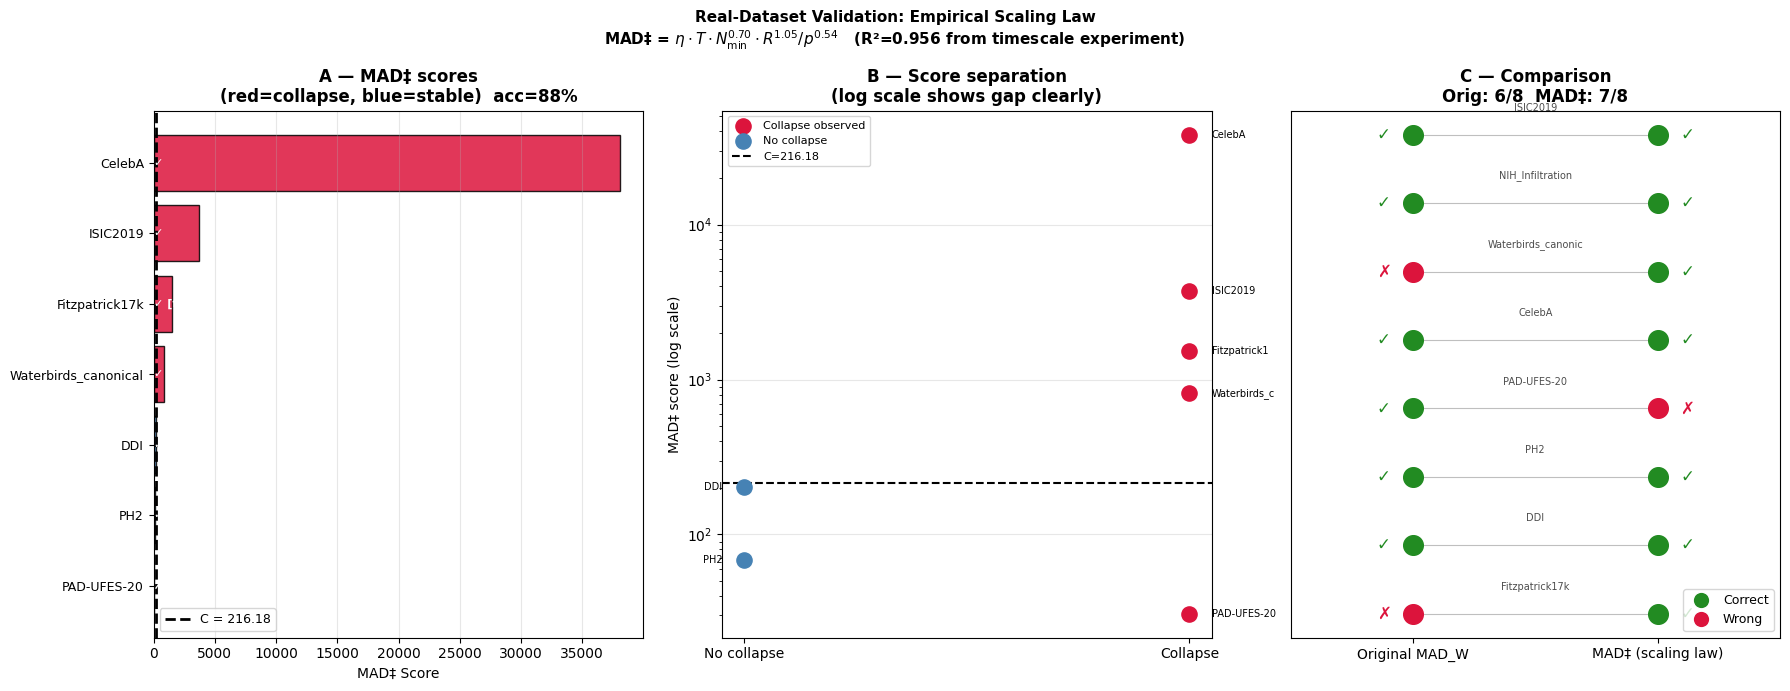

Figure saved: real_dataset_validation_figure.png


In [7]:
# ── CELL 7: Comparison figure ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'Real-Dataset Validation: Empirical Scaling Law\n'
    r'MAD‡ = $\eta \cdot T \cdot N_{\min}^{0.70} \cdot R^{1.05} / p^{0.54}$'
    f'   (R²=0.956 from timescale experiment)',
    fontweight='bold', fontsize=11)

# Panel A: MAD‡ scores with threshold
ax = axes[0]
df_plot = df_exact[df_exact['mad_exact'].notna()].copy()
df_plot['score'] = df_plot['mad_exact'].astype(float)
df_plot = df_plot.sort_values('score')

colors = ['crimson' if obs else 'steelblue' for obs in df_plot['observed']]
bars = ax.barh(range(len(df_plot)), df_plot['score'],
               color=colors, edgecolor='black', alpha=0.85)
ax.axvline(BEST_C_EXACT, color='black', linestyle='--', linewidth=2,
           label=f'C = {BEST_C_EXACT:.2f}')
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['name'], fontsize=9)
ax.set_xlabel('MAD‡ Score')
ax.set_title(f'A — MAD‡ scores\n(red=collapse, blue=stable)  acc={n_star/len(df_exact):.0%}',
             fontweight='bold')
ax.legend(fontsize=9)
for i, (_, row) in enumerate(df_plot.iterrows()):
    fl = '✓' if row['star_correct'] else '✗'
    fix = '[fix]' if row['star_correct'] and not row['orig_correct'] else ''
    ax.text(BEST_C_EXACT*0.05, i, f'{fl} {fix}', va='center',
            fontsize=8, color='white', fontweight='bold')
ax.xaxis.grid(True, alpha=0.3)

# Panel B: Score vs observed, log scale
ax2 = axes[1]
collapsing    = df_plot[df_plot['observed']==True]['score'].values
non_collapsing= df_plot[df_plot['observed']==False]['score'].values
ax2.scatter(np.ones(len(collapsing)),     collapsing,
            s=120, color='crimson', label='Collapse observed', zorder=5)
ax2.scatter(np.zeros(len(non_collapsing)), non_collapsing,
            s=120, color='steelblue', label='No collapse', zorder=5)
for s, nm in zip(collapsing,
                 df_plot[df_plot['observed']==True]['name']):
    ax2.text(1.05, s, nm[:12], va='center', fontsize=7)
for s, nm in zip(non_collapsing,
                 df_plot[df_plot['observed']==False]['name']):
    ax2.text(-0.05, s, nm[:12], va='center', fontsize=7, ha='right')
ax2.axhline(BEST_C_EXACT, color='black', linestyle='--', linewidth=1.5,
            label=f'C={BEST_C_EXACT:.2f}')
ax2.set_yscale('log')
ax2.set_xticks([0,1])
ax2.set_xticklabels(['No collapse', 'Collapse'], fontsize=10)
ax2.set_ylabel('MAD‡ score (log scale)')
ax2.set_title('B — Score separation\n(log scale shows gap clearly)',
              fontweight='bold')
ax2.legend(fontsize=8)
ax2.yaxis.grid(True, alpha=0.3)

# Panel C: Original MAD_W vs MAD‡
ax3 = axes[2]
correct_orig = df_exact['orig_correct'].values
correct_star = df_exact['star_correct'].values
names        = df_exact['name'].values
for i, (name, co, cs) in enumerate(zip(names, correct_orig, correct_star)):
    color_o = 'forestgreen' if co else 'crimson'
    color_s = 'forestgreen' if cs else 'crimson'
    ax3.scatter(0, i, color=color_o, s=200, zorder=5)
    ax3.scatter(1, i, color=color_s, s=200, zorder=5)
    ax3.plot([0,1],[i,i], color='gray', linewidth=0.8, alpha=0.5)
    ax3.text(-0.12, i, '✓' if co else '✗', ha='center', va='center',
             fontsize=12, color=color_o, fontweight='bold')
    ax3.text(1.12,  i, '✓' if cs else '✗', ha='center', va='center',
             fontsize=12, color=color_s, fontweight='bold')
    ax3.text(0.5, i+0.32, name[:18], ha='center', va='bottom', fontsize=7, alpha=0.7)
ax3.set_xlim(-0.5, 1.5)
ax3.set_xticks([0,1])
ax3.set_xticklabels(['Original MAD_W', 'MAD‡ (scaling law)'], fontsize=10)
ax3.set_yticks([])
ax3.set_title(f'C — Comparison\nOrig: {n_orig}/{len(df_exact)}  '
              f'MAD‡: {n_star}/{len(df_exact)}',
              fontweight='bold')
from matplotlib.lines import Line2D
ax3.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor='forestgreen',
           markersize=12,label='Correct'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson',
           markersize=12,label='Wrong'),
], fontsize=9, loc='lower right')

plt.tight_layout()
fig.savefig('real_dataset_validation_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: real_dataset_validation_figure.png')

In [8]:
# ── CELL 8: Summary ─────────────────────────────────────────
df_exact.to_csv('real_dataset_validation.csv', index=False)

summary = {
    'scaling_law': {
        'formula': 'MAD‡ = eta * T * N_min^a * ratio^b / p^c',
        'exponents_exact':   {'a': A_EXACT, 'b': B_EXACT, 'c': C_EXACT},
        'exponents_rounded': {'a': A_ROUND, 'b': B_ROUND, 'c': C_ROUND},
        'source': 'Timescale experiment R²=0.956 (22 uncensored runs)'
    },
    'threshold': {
        'C_exact':    round(float(BEST_C_EXACT), 4),
        'accuracy':   round(float(BEST_ACC_EXACT), 4),
        'loo_cv_acc': round(float(LOO_ACC_EXACT), 4),
    },
    'retrodiction': {
        'n_datasets':        len(df_exact),
        'mad_dagger_correct': int(n_star),
        'original_correct':  int(n_orig),
        'fixes':             int(n_fix),
        'regressions':       int(n_reg),
        'mad_dagger_acc':    round(float(n_star/len(df_exact)), 4),
        'original_acc':      round(float(n_orig/len(df_exact)), 4),
    },
    'per_dataset': df_exact[[
        'name','N_min','N_maj','ratio','p','mad_exact',
        'pred_exact','orig_pred','observed',
        'star_correct','orig_correct'
    ]].to_dict('records'),
    'honest_caveats': [
        'Exponents fitted on synthetic Gaussians (fixed geometry); '
        'geometry term (mu_cos) not yet incorporated',
        'N_min and N_maj values for some datasets (DDI, PH2, NIH) are approximate',
        'CelebA mu_cos not measured in paper notebooks — approximate value used',
        'Threshold C calibrated on same 8 datasets — LOO-CV gives honest estimate',
        'Waterbirds collapse is symmetric instability, different mechanism: '
        'scaling law may not apply',
    ]
}

with open('real_dataset_validation_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print('=== FINAL SUMMARY ===')
print(json.dumps({k:v for k,v in summary.items() if k!='per_dataset'}, indent=2))
print()
print('Files:')
for f in ['real_dataset_validation.csv',
          'real_dataset_validation_figure.png',
          'real_dataset_validation_summary.json']:
    print(f'  {f}')
print()
print('Paste all output back to Claude.')

=== FINAL SUMMARY ===
{
  "scaling_law": {
    "formula": "MAD\u2021 = eta * T * N_min^a * ratio^b / p^c",
    "exponents_exact": {
      "a": 0.7043,
      "b": 1.0479,
      "c": 0.5382
    },
    "exponents_rounded": {
      "a": 0.6666666666666666,
      "b": 1.0,
      "c": 0.5
    },
    "source": "Timescale experiment R\u00b2=0.956 (22 uncensored runs)"
  },
  "threshold": {
    "C_exact": 216.1782,
    "accuracy": 0.8571,
    "loo_cv_acc": 0.5714
  },
  "retrodiction": {
    "n_datasets": 8,
    "mad_dagger_correct": 7,
    "original_correct": 6,
    "fixes": 2,
    "regressions": 1,
    "mad_dagger_acc": 0.875,
    "original_acc": 0.75
  },
  "honest_caveats": [
    "Exponents fitted on synthetic Gaussians (fixed geometry); geometry term (mu_cos) not yet incorporated",
    "N_min and N_maj values for some datasets (DDI, PH2, NIH) are approximate",
    "CelebA mu_cos not measured in paper notebooks \u2014 approximate value used",
    "Threshold C calibrated on same 8 datasets \